(ode:integration-schemes)=
# Integration schemes

The choice of a integration scheme usually involves a trade-off between, **stability**, **computational cost**, **fidelity** (accuracy/order, numerical damping/change of phase/amplifications of fast modes - see transfer function, and stiff problems -, energy conservation for conservative systems - see simplectic methods,...)

Link to [Z-transform](complex:z-transform) for discrete-time signals.



## Contents


```{dropdown} Contents
:open:

**Schemes.**

* Euler methods, CN
* RK
* Multi-step: AB, AM, BDF,...
* Other methods:
  * Newmark-beta, Verlet (Leapfrog),...

**Concepts.**

* Convergence:
* Consistence:
* Stability:
  * zero-stability
  * A-stability
  * L-stability
* Stiffness

**Theoretical results**

* Dahlquist barriers
* Lax-Richtmyer

**References**

* [Advantage of L-stability compared to A-stability](https://math.stackexchange.com/questions/1466978/advantage-of-l-stability-compared-to-a-stability), Mathematics Stack Exchange.

```

## Families of integration methods

* Linear multi-steps:
  * from Lagrange approximation of integral: AB (explicit, $s$-step with max order $s$), AM (implicit, $s$-step with max order $s+1$)
  * from approximation of derivative: BDF (implicit)

## Concepts

### Local truncation error and Consistency



Let

$$y_{n+1} = \Psi(t_{n+1}; y_n, ..., y_{n-k+1}; h, f(\cdot)) = y_n + h A(t_{n+1}; y_n, ..., y_{n-k+1}; h, f(\cdot)) \ ,$$

the numerical method for the solution of the initial value problem

$$\begin{aligned}
  \dot{y}(t) & = f(y(t),t) \\
  y(0) & = y_0 \ . 
\end{aligned}$$

The **local truncation error** is the error produced by **one step of the method**, i.e.

$$\delta_{n+k}^h := y_{n+k} - y(t_{n+k}) \ ,$$

being $y_{n+k}$ the result of one step of the numerical method, and $y(t_{n+k})$ the exact solution using the same initial conditions (assuming, there's no error in previous steps). A numerical method is defined **consistent** if

$$\lim_{h \rightarrow 0} \frac{\delta^h_{n+k}}{h} = 0 \ .$$

The method has **order** $p$ if 

$$\delta^h_{n+k} = O(h^{p+1}) \quad , \quad \text{for } h \rightarrow 0 \ .$$



### Global truncation error and Convergence



The **global truncation error** $e_n$ is the accumulation of the error up to time $t_n$,

$$e_n^h := y_{n} - y(t_n) \ .$$

A numerical method is defined **convergent** if 

$$\lim_{h \rightarrow 0} \max_n | e_{n} | = 0 \ .$$



#### Recurrence relation for One-step methods

A one-step method reads

$$y_{n+1} = \Psi(t_{n+1}; y_n; h, f(\cdot)) = y_n + h A(t_{n+1}; y_n; h, f(\cdot)) \ ,$$


A recurrence relation exists between the global and the local truncation error

...

*this implies some bound of the global error, see [wiki](https://en.wikipedia.org/wiki/Truncation_error_(numerical_integration))*

### Stability of a linear system


Linear homogeneous equation (or system?)

$$\begin{aligned}
  \dot{y} & = \lambda y \\
  y(0) & = y_0 \ ,
\end{aligned}$$

is a first test for the stability of a numerical method. The problem has the exact solution

$$y(t) = y_0 e^{\lambda t} \ ,$$

and is **asymptotically stable** if $\text{re}\{\lambda\} < 0$, as 

$$\lim_{t \rightarrow +\infty} y(t) = \lim_{t \rightarrow +\infty} y_0 e^{\lambda t} =  \lim_{t \rightarrow +\infty} y_0 e^{\text{re}\{\lambda\} t} e^{j \, \text{im}\{\lambda\} t} \ . $$

Forced linear equation (or system?)

$$\dot{y} = \lambda y + u \ .$$

The exact solution converges to the forced solution if the system is asymptotically stable, For periodic forcing, the behavior can be evaluated in frequency (Laplace or Fourier) domain

$$y(s) = \frac{1}{s - \lambda} u(s) \ .$$

#### A-stability

A-stability ensures the numerical method doesn't explode in the simulation of a asymptotically stable system.

A numerical method is defined A-stable if its stability region includes the whole left half plane.

#### L-stability

Let $z := h \lambda$. For **one-step methods**, it's possible to define a **scalar transfer function** $G(z)$ between $y_{n}$ and $y_{n+1}$,

$$y_{n+1} = G(z) y_n \ .$$

For **multi-step methods**... proerties of characteristic polynomial and its roots

For **systems**... amplification matrix...


L-stability ensures that the method damps extremely fast - **stiff** - modes, that are usually physically irrelevant but that can be numerically troublesome. A method is defined L-stable if

$$\lim_{z \rightarrow -\infty} G(z) = 0 \ .$$

#### 0-stability

0-stability (of a numerical method for a certain differential equation on a given interval) if a perturbation in the starting value of size $\varepsilon$ causes the numerical solution over the time interval to change less than $K \varepsilon$ for some $K$ that doesn't depend on the time-step $h$.

It's enough to check the conditions for the differential equation $y' = 0$ **todo** *why? check it!*

A linear multi-step method is zero-stable **iif** the root condition (analogous to at least marginally stable system, i.e. roots with absolute value $|z| < 1$, or $|z| = 1$ with multiplicity $= 1$) is satisfied.


### Some schemes


#### Homogeneous equation

$$\dot{y} = f(t,y) = \lambda y \ .$$



**Explicit Euler.**

$$y_{n+1} = y_{n} + h f(y_n, t_n) = y_n + h \lambda y_n = ( 1 + h \lambda ) y_n \ .$$

The solution of this difference equation with initial condition $y_0$ reads

$$y_{n} = ( 1 + h \lambda )^n y_0 \ .$$

**Implicit Euler.**

$$y_{n+1} = y_{n} + h f(y_{n+1}, t_{n+1}) = y_n + h \lambda y_{n+1} \ .$$

The solution of this difference equation with initial condition $y_0$ reads

$$y_{n} = \frac{1}{( 1 - h \lambda )^n} y_0 \ .$$

**Crank-Nicolson.**

$$y_{n+1} = y_n + \frac{h}{2} \left[ f(y_{n}, t_{n}) + f(y_{n+1}, t_{n+1}) \right] = y_n + \frac{h}{2} \left[ \lambda y_{n} + \lambda y_{n+1} \right] \ .$$

$$y_{n} = \left[ \frac{1 + \lambda h / 2}{1 - \lambda h / 2} \right]^n y_0 \ .$$





**BDF 2.** BDF 2 is a multi-step approach, so either $Z$-transform of the conversion to a one-step 2-dimensional system is required to discuss its stability properties, and transfer function.

$$y_{n+1} - \frac{4}{3} y_{n} + \frac{1}{3} y_{n-1} = \frac{2}{3} h f(t_{n+1}, y_{n+1}) $$

$$y_{n+1} - \frac{4}{3} y_{n} + \frac{1}{3} y_{n-1} = \frac{2}{3} h \lambda y_{n+1} $$

**Z-transform.** Using the definition $\zeta := \lambda h$, and applying the $Z$-transform,

$$\begin{aligned}
  0 & = \left[ \left( 1 - \frac{2}{3} z \right) - \frac{4}{3} \zeta^{-1} + \frac{1}{3} \zeta^{-2} \right] Y(\zeta) \\
\end{aligned}$$

 the characteristic polynomial reads

$$\begin{aligned}
  0 & = \pi(\zeta; z) = \left( 3 - 2 z \right) \zeta ^2 - 4 \zeta + 1 \ .
\end{aligned}$$

The roots of the polynomial depend on $z \in \mathbb{C}$, and the system is stable if all the roots have $|\zeta_k| \le 1$. This condition can be summarized with the condition of **spectral radius** of the matrix $\mathbf{A}$ of the one-step system, $\rho(\mathbf{A}) = \max |\lambda_k| < 1$.


**Reduction of difference equation to a one-step system.** The 2-step difference equation above

$$y_{n+1} - \frac{4}{3 - 2 z} y_{n} + \frac{1}{3 - 2 z} y_{n} = 0$$

can be recast as a system, $y_n = z_{1,n}$, $y_{n-1} = z_{0,n}$

$$\begin{aligned}
  z_{0,n+1} & = z_{1,n} \\
  z_{1,n+1} & = \frac{4}{3 - 2 z} z_{1,n} - \frac{1}{3 - 2 z} z_{0,n}
\end{aligned}$$

or using matrix formalism

$$\mathbf{z}_{n+1} = \mathbf{A} \mathbf{z}_n \ ,$$

with $\mathbf{A} = \begin{bmatrix} \cdot & 1 \\ -\frac{1}{3 - 2 z} & \frac{4}{3 - 2 z} \end{bmatrix}$. The eigenvalues of the system follows from the condition

$$0 = \zeta \left( \zeta - \frac{4}{3 - 2 z} \right) + \frac{1}{3-2 z} \ , $$

i.e. the same condition as $\pi(\zeta; z) = 0$.

**L-stability.** As $\rightarrow +\infty$, the polynomials goes to $\pi(z \rightarrow + \infty; \zeta) \sim - \frac{2}{3} z \zeta^2$ and thus the roots goes to $z \rightarrow + \infty$.


**Methods for second-order equations.**

$$\ddot{\mathbf{x}} = \mathbf{f}(t, \mathbf{x}) \ ,$$

or as a first-order system

$$\begin{bmatrix} \dot{\mathbf{x}} \\ \dot{\mathbf{v}} \end{bmatrix} = \begin{bmatrix} \mathbf{v} \\ \mathbf{f}(\mathbf{x},t) \end{bmatrix} \ .$$

A test second-order homogeneous equation may be the dynamical equation of an undapmed mass-spring system,

$$\ddot{x} + \Omega^2 x = 0 \ ,$$

being $( d_t + i \Omega )( d_t - i \Omega ) x = 0$. This analysis can be performed with a system with conjugate complex eigenvalues $\lambda = \sigma + j \omega$ and $\lambda^* = \sigma - j \omega$, sot that the test equation becomes

$$\begin{aligned}
  0 
  & = ( d_t - \sigma - i \omega )( d_t - \sigma + i \omega ) x = \\
  & = d_{tt} x - 2 \sigma d_t x + ( \sigma^2 + \omega^2 ) \ .
\end{aligned}$$


**Leapfrog method.**

$$\left\{\begin{aligned}
  x_{i+1} & = x_i + h v_i + \frac{h^2}{2} f(x_i) \\
  v_{i+1} & = v_i + \frac{h}{2} \left( f(x_i) + f(x_{i+1}) \right) \ .
\end{aligned}\right.$$

**Verlet method.** ...

**Newmark method.** ...









Test equation has $f(x) = - \Omega^2 x$, so that Leapfrog method applied to the test problem reads


$$\left\{\begin{aligned}
  x_{i+1} & = x_i + h v_i - \frac{h^2 \Omega^2}{2} x_i\\
  v_{i+1} & = v_i - \Omega^2 \frac{h}{2} \left(x_i + x_{i+1} \right) \ .
\end{aligned}\right.$$

so that the $\mathbf{z}_{i+1}$ state can be written as a function of the $\mathbf{z}_i$ state

$$\begin{bmatrix} 1 & \cdot \\ \frac{h \Omega^2}{2} & 1 \end{bmatrix} \begin{bmatrix} x \\ v \end{bmatrix}_{i+1} = \begin{bmatrix} 1 - \frac{h^2 \Omega^2}{2} & h \\ -\frac{h \Omega^2}{2} & 1 \end{bmatrix} \begin{bmatrix} x \\ v \end{bmatrix}_i$$

or

$$\begin{aligned}
  \begin{bmatrix} x \\  h v \end{bmatrix}_{i+1} 
  & = \begin{bmatrix} 1 & \cdot \\ -\frac{h \Omega^2}{2} & 1 \end{bmatrix}  \begin{bmatrix} 1 - \frac{h^2 \Omega^2}{2} & 1 \\ -\frac{h^2 \Omega^2}{2} & 1 \end{bmatrix} \begin{bmatrix} x \\ h v \end{bmatrix}_i = \\
  & = \begin{bmatrix} 1 - \frac{h^2 \Omega^2}{2} & 1 \\ - h^2 \Omega^2 \left( 1 - \frac{h^2 \Omega^2}{4} \right) &  1-\frac{h^2 \Omega^2}{2} \end{bmatrix} \begin{bmatrix} x \\ h v \end{bmatrix}_i \ .
\end{aligned}$$




Generalized test equation has $f(x,v) = 2 \sigma v - ( \sigma^2 + \omega^2) x = - 2 \xi \Omega v - \Omega^2 x$, with 

$$\begin{aligned}
 \Omega^2 & = \sigma^2 + \omega^2 \\
 \sigma & = - \xi \Omega  \qquad \rightarrow \qquad \xi = -\frac{\sigma}{\Omega} = - \frac{\sigma}{\sqrt{\sigma^2 + \omega^2}} \\
\end{aligned}$$

Leapfrog method applied to the test problem reads

$$\left\{\begin{aligned}
  x_{i+1} & = x_i + h v_i + \frac{h^2 }{2} \left( - \Omega^2 x_i - 2 \xi \Omega v_i \right)\\
  v_{i+1} & = v_i + \frac{h}{2} \left[ -\Omega^2 \left(x_i + x_{i+1} \right) - 2 \xi \Omega \left(v_i + v_{i+1} \right) \right] \ .
\end{aligned}\right.$$


**todo** *check!*




$$\begin{bmatrix} 1 & \cdot \\ \frac{h^2 \Omega^2}{2} & 1 + \xi h \Omega \end{bmatrix} \begin{bmatrix} x \\ h v \end{bmatrix}_{i+1} = \begin{bmatrix} 1 - \frac{h^2 \Omega^2}{2} & 1 - \xi h \Omega \\ -\frac{h^2 \Omega^2}{2} & 1 - \xi h \Omega \end{bmatrix} \begin{bmatrix} x \\ h v \end{bmatrix}_i$$


$$\begin{aligned}
  \begin{bmatrix} x \\  h v \end{bmatrix}_{i+1} 
  & = \begin{bmatrix} 1 & \cdot \\ -\frac{h^2 \Omega^2}{2 (1+\xi h \Omega)} & \frac{1}{1+\xi h \Omega} \end{bmatrix} \begin{bmatrix} 1 - \frac{h^2 \Omega^2}{2} & 1 - \xi h \Omega \\ -\frac{h^2 \Omega^2}{2} & 1 - \xi h \Omega \end{bmatrix} \begin{bmatrix} x \\ h v \end{bmatrix}_i = \\
  & = \begin{bmatrix} 1 - \frac{h^2 \Omega^2}{2} & 1 - \xi h \Omega \\ - \frac{h^2 \Omega^2}{1+\xi h \Omega} \left( 1 - \frac{h^2 \Omega^2}{4} \right) & \frac{1 - \xi h \Omega}{1 + \xi h \Omega} \left( 1-\frac{h^2 \Omega^2}{2} \right) \end{bmatrix} \begin{bmatrix} x \\ h v \end{bmatrix}_i \ .
\end{aligned}$$


* if $\xi^2 \ge 1$, then the eigenvalues are real
* if $\xi^2 \le 1$, then the eigenvalues are conjugate complex, $s_{1,2} = -\xi \Omega \mp j \Omega \sqrt{1 - \xi^2}$

#### Forced equation



$$\dot{y} = \lambda y(t) + u(t)$$

**Explicit Euler.**

$$y_{n+1} = y_{n} + h f(y_n, t_n) = y_n + h \lambda y_n = ( 1 + h \lambda ) y_n + h u(t_n) \ .$$

...

**Implicit Euler.**

$$y_{n+1} = y_{n} + h f(y_{n+1}, t_{n+1}) = y_n + h \lambda y_{n+1} + h y(t_n) \ .$$

...

**Crank-Nicolson.**

$$y_{n+1} = y_n + \frac{h}{2} \left[ f(y_{n}, t_{n}) + f(y_{n+1}, t_{n+1}) \right] = y_n + \frac{h}{2} \left[ \lambda y_{n} + \lambda y_{n+1} \right] + \frac{h}{2} \left[ u(t_n) + u(t_{n+1}) \right] \ .$$

...

#### A-stability

In [98]:
import numpy as np
import matplotlib.pyplot as plt

ampl_fun_ee = lambda z: 1 + z
ampl_fun_ie = lambda z: 1 / ( 1 - z )
ampl_fun_cn = lambda z: ( 1 + z/2 ) / ( 1 - z/2 )

A_bdf2 = lambda z: np.array([[.0, 1.], [-1/(3-2*z), 4/(3-2*z)]])

def ampl_A_fun(z, A_fun):
    evals = np.linalg.eigvals(A_fun(z))
    ieval = np.argmax(np.absolute(evals))
    
    return evals[ieval]

def A_lf(z):
    sigh, omh = np.real(z), np.imag(z)

    bh = - sigh
    ch2 = sigh**2 + omh**2
    # if c == 0:
    #     return np.eye(2)

    n1 = 1. - bh
    n2 = 1. - ch2/2.
    n4 = 1. - ch2/4.
    d1 = 1 + bh
    
    return np.array([[n2, n1], [-ch2*n4/d1, n1/d1*n2]])
    

ampl_fun_bdf2 = lambda z: ampl_A_fun(z, A_bdf2)
ampl_fun_lf = lambda z: ampl_A_fun(z, A_lf)

# ampl_fun_lf = lambda z: np.max(np.absolute(np.linalg.eigvals(A_lf(z))))

ampl_funs = {
    'EE': ampl_fun_ee,
    'IE': ampl_fun_ie,
    'CN': ampl_fun_cn,
    'BDF2': ampl_fun_bdf2,
    'Leapfrog': ampl_fun_lf
}
n_methods = len(ampl_funs)

def complex_amplification_fun(ampl_fun):
    x = np.linspace(-5.001, 5.001, 200)
    y = np.linspace(-5.001, 5.001, 200)
    X, Y = np.meshgrid(x, y)
    Z = X + 1j*Y

    return X,Y, np.vectorize(ampl_fun)(Z)



In [99]:
print(ampl_funs.keys())

dict_keys(['EE', 'IE', 'CN', 'BDF2', 'Leapfrog'])


In [100]:
def integrate_test_ee(lam, x0, tv,):
    dt = tv[1] - tv[0]
    nt = len(tv)
    xx = np.zeros(nt, dtype=complex);   xx[0] = x0

    for it in np.arange(len(tv)-1):
        xx[it+1] = ( 1. + dt * lam ) * xx[it]

    return xx


def integrate_test_ie(lam, x0, tv,):
    dt = tv[1] - tv[0]
    nt = len(tv)
    xx = np.zeros(nt, dtype=complex);  xx[0] = x0

    for it in np.arange(len(tv)-1):
        xx[it+1] = xx[it] / ( 1. - dt * lam )

    return xx


def integrate_test_cn(lam, x0, tv,):
    dt = tv[1] - tv[0]
    nt = len(tv)
    xx = np.zeros(nt, dtype=complex);   xx[0] = x0

    for it in np.arange(len(tv)-1):
        xx[it+1] = xx[it] * ( 1. + dt * lam/2 ) / ( 1. - dt * lam/2 )

    return xx


def integrate_test_bdf2(lam, x0, tv,):
    dt = tv[1] - tv[0]
    nt = len(tv)
    xx = np.zeros(nt, dtype=complex);   xx[0] = x0

    #> First step: implicit Euler
    xx[1] = xx[0] / ( 1 - dt * lam )
     
    for it in np.arange(len(tv)-1):
        xx[it+1] = ( 4*xx[it] - xx[it-1] ) / ( 3 - 2 * dt * lam )

    return xx


def integrate_test_leapfrog(lam, z0, tv,):

    sig, om = np.real(lam), np.imag(lam)
    b = - sig
    c = sig**2 + om**2
    
    dt = tv[1] - tv[0]
    nt = len(tv)
    
    xx = np.zeros(nt, dtype=complex);   xx[0] = z0[0]
    vv = np.zeros(nt, dtype=complex);   vv[0] = z0[1]

    for it in np.arange(len(tv)-1):
        xx[it+1] = xx[it] + dt * vv[it] + dt**2 / 2 * ( -2*b * vv[it] - c * xx[it] )
        vv[it+1] = ( vv[it] + dt/2 * ( -c* ( xx[it] + xx[it+1] ) - 2*b * vv[it] ) ) / ( 1 + b * dt )
    
    return xx



In [101]:
from tqdm import tqdm

dt, nt = 1., 100
tv = np.arange(nt) * dt

nz_real = 17
nz_imag = 17
z_real = np.linspace(-5.123, 5.123, nz_real)
z_imag = np.linspace(-5.123, 5.123, nz_imag)

Zreal, Zimag = np.meshgrid(z_real, z_imag)

XX = { k: {  } for k in ampl_funs.keys() }

XX['EE'  ] = { 'ic': 1., 'fun': integrate_test_ee, }
XX['IE'  ] = { 'ic': 1., 'fun': integrate_test_ie, }
XX['CN'  ] = { 'ic': 1., 'fun': integrate_test_cn, }
XX['BDF2'] = { 'ic': 1., 'fun': integrate_test_bdf2, }
XX['Leapfrog'] = { 'ic': [ 1., .0 ], 'fun': integrate_test_leapfrog, }

for k in XX:
     XX[k]['stability'] = np.zeros((nz_real, nz_imag))


#> Numerical integration of test equation
for method in XX:
    integrate_test = XX[method]['fun']
    x0 = XX[method]['ic']

    i_imag = 0
    for zi in z_imag:
        i_real = 0
        for zr in z_real:
            z = zr + 1j * zi
    
            xx = integrate_test(z, x0, tv)
            
            #> Check if diverging or not
            if ( np.max(np.abs(xx)) > 1.001 ):
                XX[method]['stability'][i_imag, i_real] = 0
            else:
                XX[method]['stability'][i_imag, i_real] = 1
 
            i_real += 1
        
        i_imag += 1



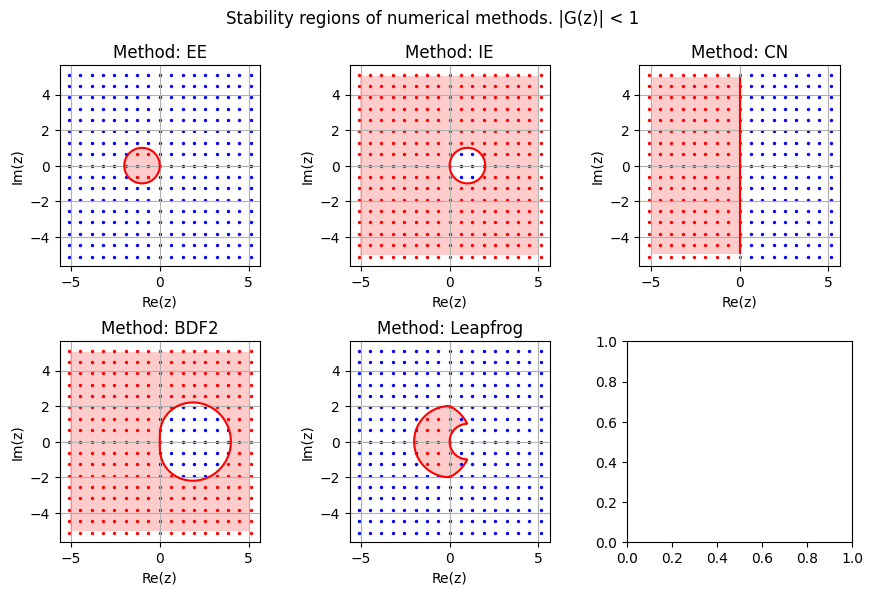

In [102]:
#> 
ncols = 3
nrows = ( n_methods - 1 ) // ncols + 1

fig, ax = plt.subplots(nrows, ncols, figsize=(ncols*3, nrows*3))

i_method = 0
for label, fun in ampl_funs.items():

    irow = i_method // ncols
    icol = i_method % ncols

    X, Y, G = complex_amplification_fun(fun)
    
    ax[irow, icol].contour(X, Y, np.absolute(G), levels=[1.0], colors='r')
    ax[irow, icol].contourf(X, Y, np.absolute(G), levels=[0., 1.0], colors=['#ffcccc'])
    ax[irow, icol].set_title(f"Method: {label}")
    ax[irow, icol].set_aspect("equal")
    ax[irow, icol].set_xlabel(f"Re(z)"); ax[irow, icol].set_ylabel(f"Im(z)"); ax[irow, icol].grid()

    #>
    stable_mask = ( XX[label]['stability'] == 1 )
    unstable_mask = ( XX[label]['stability'] == 0 )
    
    ax[irow, icol].scatter( Zreal[stable_mask], 
                            Zimag[stable_mask],
                            s=2, color='red', label='Stable')
   
    ax[irow, icol].scatter( Zreal[unstable_mask], 
                            Zimag[unstable_mask],
                            s=2, color='blue', label='Unstable')
    
    i_method += 1  


fig.suptitle("Stability regions of numerical methods. |G(z)| < 1")
fig.tight_layout()
# plt.axhline(0, color='black', lw=1)
# plt.axvline(0, color='black', lw=1)
# plt.grid(True, linestyle='--')
plt.show()

**A-stability.** Implicit Euler and Crank-Nicolson methods are A-stable, while explicit Euler is not.

#### G(z): absolute value and phase

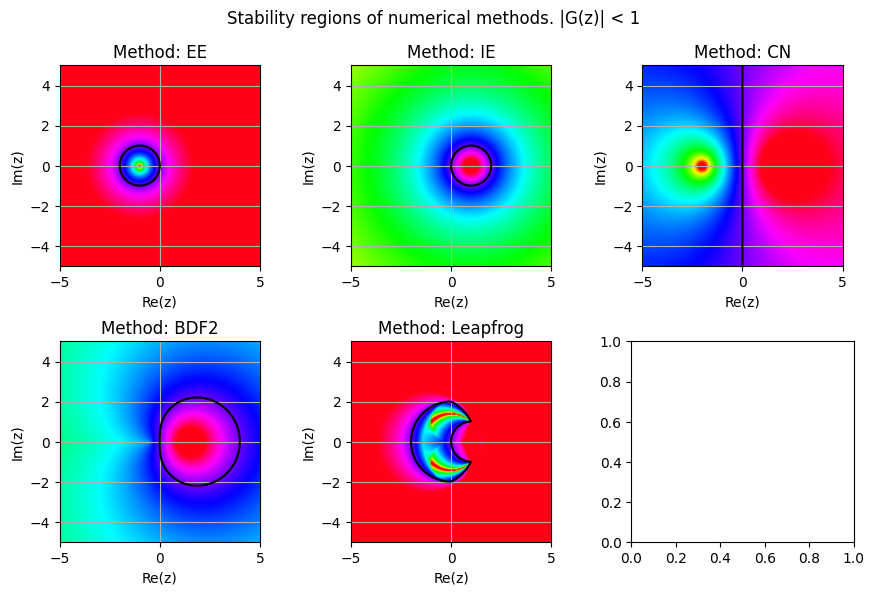

In [103]:

ampl_fun_bdf2 = lambda z: np.max(np.abs(np.linalg.eigvals(A_bdf2(z))))    
ampl_fun_lf = lambda z: np.max(np.abs(np.linalg.eigvals(A_lf(z))))

ampl_funs = {
    'EE': ampl_fun_ee,
    'IE': ampl_fun_ie,
    'CN': ampl_fun_cn,
    'BDF2': ampl_fun_bdf2,
    'Leapfrog': ampl_fun_lf_2
}
n_methods = len(ampl_funs)

#> 
ncols = 3
nrows = ( n_methods - 1 ) // ncols + 1

fig, ax = plt.subplots(nrows, ncols, figsize=(ncols*3, nrows*3))

i_method = 0
for label, fun in ampl_funs.items():

    irow = i_method // ncols
    icol = i_method % ncols

    X, Y, G = complex_amplification_fun(fun)
    ax[irow, icol].contour(X, Y, np.absolute(G), levels=[1.0], colors='black')
    # ax[irow, icol].contourf(X, Y, np.abs(G), levels=[0., 1.0], colors=['#ffcccc'])
    ax[irow, icol].pcolormesh(X, Y, np.log(np.absolute(G)), cmap='hsv', shading='gouraud', vmin=-3, vmax=1.)
    ax[irow, icol].set_title(f"Method: {label}")
    ax[irow, icol].set_aspect("equal")
    ax[irow, icol].set_xlabel(f"Re(z)"); ax[irow, icol].set_ylabel(f"Im(z)"); ax[irow, icol].grid()

    i_method += 1

fig.suptitle("Stability regions of numerical methods. |G(z)| < 1")
fig.tight_layout()
# plt.axhline(0, color='black', lw=1)
# plt.axvline(0, color='black', lw=1)
# plt.grid(True, linestyle='--')
plt.show()

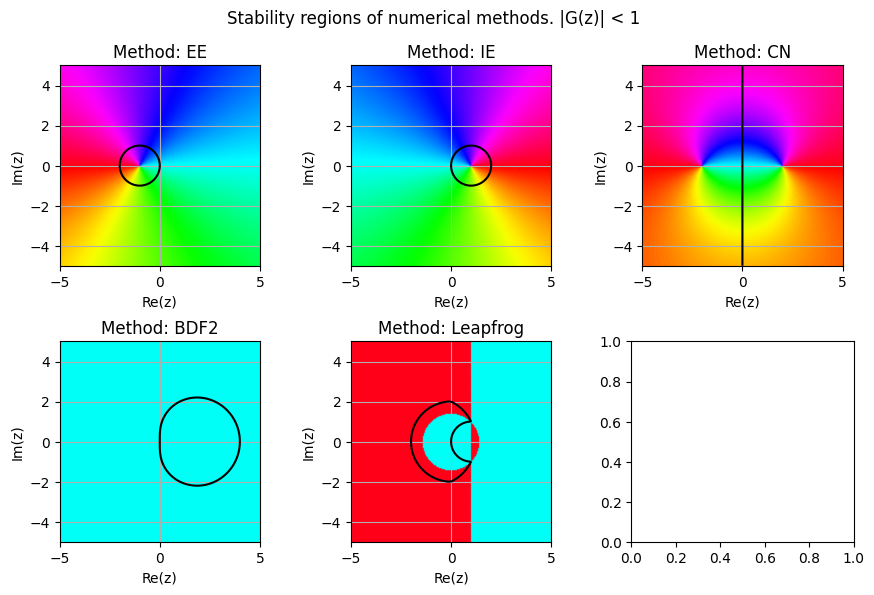

In [25]:

fig, ax = plt.subplots(nrows, ncols, figsize=(ncols*3, nrows*3))

i_method = 0
for label, fun in ampl_funs.items():

    irow = i_method // ncols
    icol = i_method % ncols

    X, Y, G = complex_amplification_fun(fun)
    ax[irow, icol].contour(X, Y, np.abs(G), levels=[1.0], colors='black')
    # ax[irow, icol].contourf(X, Y, np.abs(G), levels=[0., 1.0], colors=['#ffcccc'])
    ax[irow, icol].pcolormesh(X, Y, np.angle(G), cmap='hsv', shading='gouraud', vmin=-np.pi, vmax=np.pi)
    ax[irow, icol].set_title(f"Method: {label}")
    ax[irow, icol].set_aspect("equal")
    ax[irow, icol].set_xlabel(f"Re(z)"); ax[irow, icol].set_ylabel(f"Im(z)"); ax[irow, icol].grid()

    i_method += 1

fig.suptitle("Stability regions of numerical methods. |G(z)| < 1")
fig.tight_layout()
# plt.axhline(0, color='black', lw=1)
# plt.axvline(0, color='black', lw=1)
# plt.grid(True, linestyle='--')
plt.show()

#### G(z) on the real axis

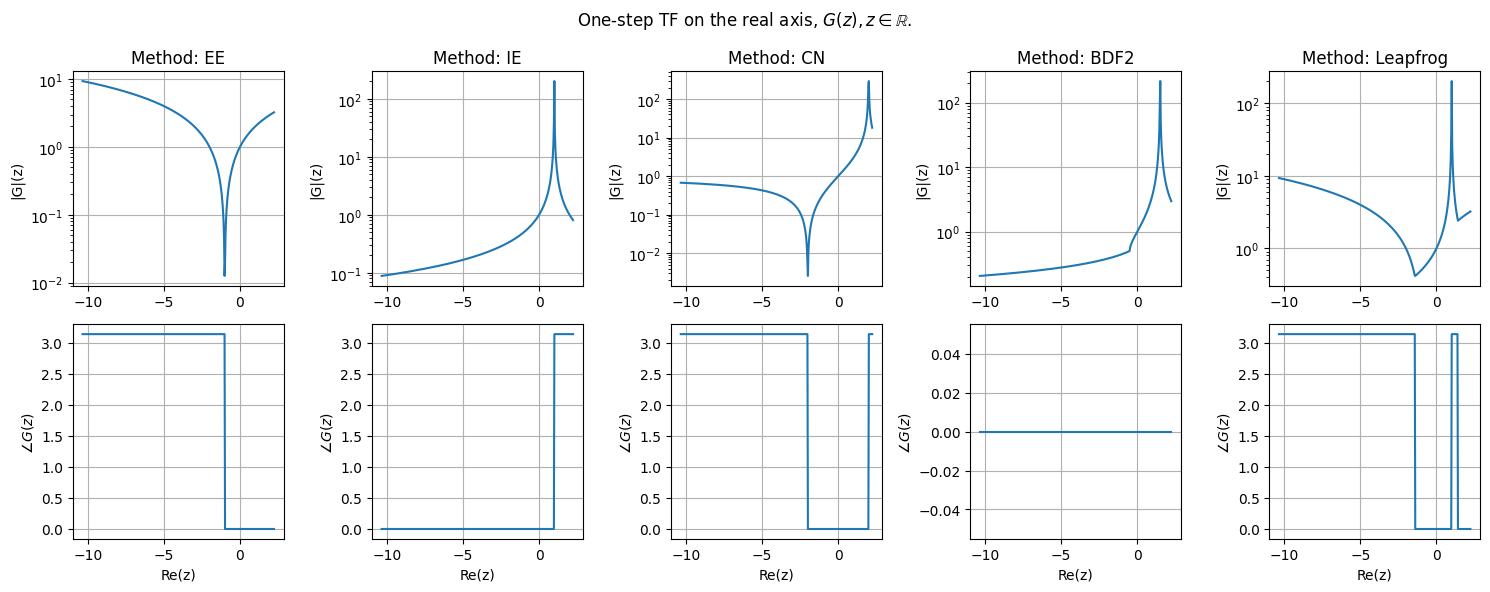

In [24]:
fig, ax = plt.subplots(2,n_methods, figsize=(n_methods*3, 2*3))
i_method = 0

for label, fun in ampl_funs.items():

    x = np.linspace(-10.34324, 2.2343242, 400)
    G = np.vectorize(fun)(x)
    
    ax[0,i_method].plot(x, np.abs(G))
    ax[0,i_method].set_title(f"Method: {label}")
    ax[0,i_method].set_ylabel(f"|G|(z)"); ax[0,i_method].grid()
    ax[0,i_method].set_yscale("log")
    ax[1,i_method].plot(x, np.angle(G))
    ax[1,i_method].set_ylabel(r"$\angle G(z)$"); ax[1,i_method].grid()
    ax[1,i_method].set_xlabel(f"Re(z)"); 

    i_method += 1

fig.suptitle(r"One-step TF on the real axis, $G(z), z \in \mathbb{R}$.")
fig.tight_layout()
plt.show()


#### G(z) on the imaginary axis

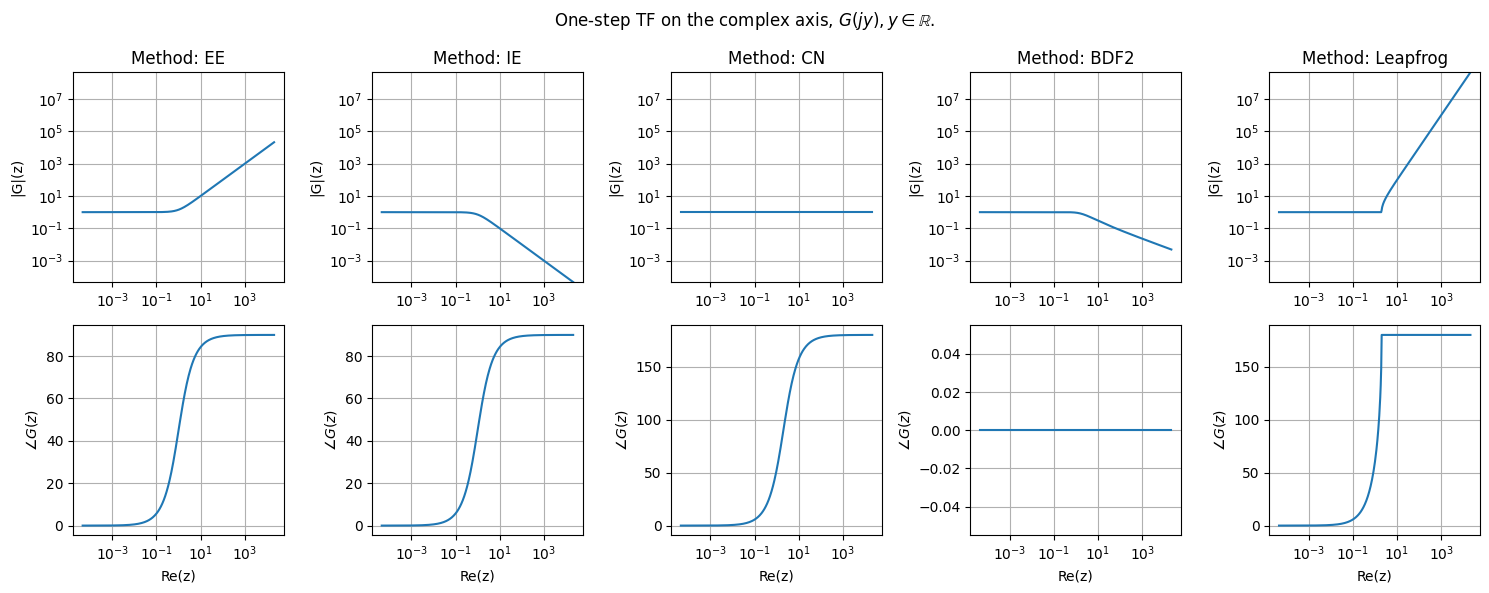

In [23]:
fig, ax = plt.subplots(2,n_methods, figsize=(n_methods*3, 2*3))
i_method = 0


min_absGs, max_absGs = [], []

for label, fun in ampl_funs.items():

    y = np.logspace(-4.3423, 4.32432, 400)
    G = np.vectorize(fun)(1j * y)

    min_absGs += [ np.min(np.abs(G)) ]
    max_absGs += [ np.max(np.abs(G)) ]
    
    ax[0,i_method].plot(y, np.abs(G))
    ax[0,i_method].set_title(f"Method: {label}")
    ax[0,i_method].set_ylabel(f"|G|(z)"); ax[0,i_method].grid()
    ax[0,i_method].set_yscale("log")
    ax[1,i_method].plot(y, np.angle(G) * 180/np.pi)
    ax[1,i_method].set_ylabel(r"$\angle G(z)$"); ax[1,i_method].grid()
    ax[1,i_method].set_xlabel(f"Re(z)");

    ax[0,i_method].set_xscale("log");  ax[1,i_method].set_xscale("log")

    i_method += 1

min_absG = np.min(min_absGs)
max_absG = np.max(max_absGs)

for i in np.arange(i_method):
    ax[0,i].set_ylim(min_absG, max_absG)


fig.suptitle(r"One-step TF on the complex axis, $G(j y), y \in \mathbb{R}$.")
fig.tight_layout()
# plt.axhline(0, color='black', lw=1)
# plt.axvline(0, color='black', lw=1)
# plt.grid(True, linestyle='--')
plt.show()

**Remark.** Here the info about phase in BDF2 and Leapfrog methods is lost, as the radial spectrum is shown.

**L-stable methods.** Among the methods shown here, only IE and BDF2 are L-stable, i.e. with $|G(z \rightarrow +\infty)| \rightarrow 0$

### Dahlquist barriers - for linear multi-step methods

**First Dahlquist barrier.**
* A zero-stable and linear q-step multis-tep method has maximum order of convergence $q+1$ if $q$ is odd, $q+2$ if $q$ is even. If the method is explicit, maximum order of convergence is $q$.

**Second Dahlquist barrier.** 
* No explicit linear multi-step method is A-stable
* Maximum order of an (implicit) A-stable linear multi-step method is 2
* Among the A-stable multi-step methods of order 2, the trapezoidal rule has the smallest error constant

A **linear multi-step method** for the equation $y'=f(t,y)$ with initial conditions $y(t_0) = y_0$, reads

$$\sum_{j=0}^{s} a_j y_{n+j} = h \sum_{j=0}^{s} b_j f(t_{n+j}, y_{n+j})$$

If $b_0 = 0$, the method is explicit, otherwise it's implicit as the unknown $y_{n+s}$ appears in both the LHS and the RHS.

**A-stability.** For the equation $y' = \lambda y$, i.e. $f(t,y) = \lambda y$, the $Z$-transformed integration step becomes

$$0 = \sum_{j=0}^{s} (a_j - h \lambda b_j ) \zeta^{j-s} = \rho(\zeta) - z \sigma(\zeta) = \pi(\zeta, z) \ ,$$

with $z := h \lambda$.

For explicit methods, $b_0 = 0$, the degree of $\sigma(\zeta)$ is lower than the degree of $\rho(\zeta)$

...